In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances

In [2]:
np.random.seed(42)

X_2D = np.random.rand(100, 2)

X_2D.shape

(100, 2)

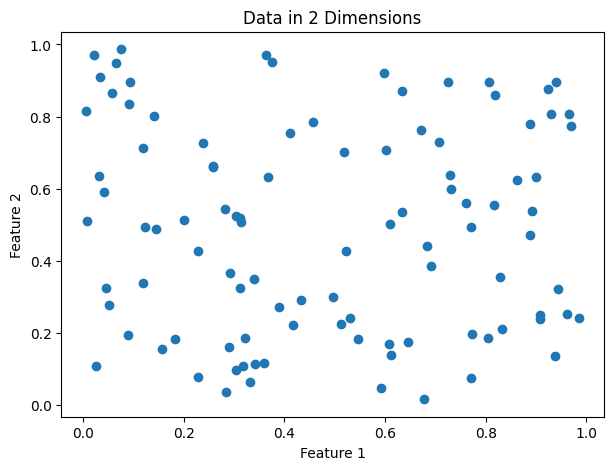

In [3]:
plt.figure(figsize=(7, 5))

plt.scatter(X_2D[:, 0], X_2D[:, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Data in 2 Dimensions")

plt.show()

In [4]:
dimensions = [2, 10, 50, 100, 500]

datasets = {}

for d in dimensions:
    datasets[d] = np.random.rand(100, d)

In [5]:
for d, X in datasets.items():
    print(f"{d} dimensions:", X.shape)

2 dimensions: (100, 2)
10 dimensions: (100, 10)
50 dimensions: (100, 50)
100 dimensions: (100, 100)
500 dimensions: (100, 500)


In [6]:
distance_results = []

for d, X in datasets.items():

    distances = pairwise_distances(X)

    # Ignore distance from a point to itself
    non_zero_distances = distances[distances > 0]

    distance_results.append({
        "Dimensions": d,
        "Mean Distance": non_zero_distances.mean(),
        "Minimum Distance": non_zero_distances.min(),
        "Maximum Distance": non_zero_distances.max()
    })

distance_df = pd.DataFrame(distance_results)

distance_df

,Dimensions,Mean Distance,Minimum Distance,Maximum Distance
0,2,0.530910,0.007924,1.291566
1,10,1.289361,0.408039,2.042470
2,50,2.870075,1.916082,3.682801
3,100,4.077597,3.230250,4.954180
4,500,9.104488,8.303741,10.035969


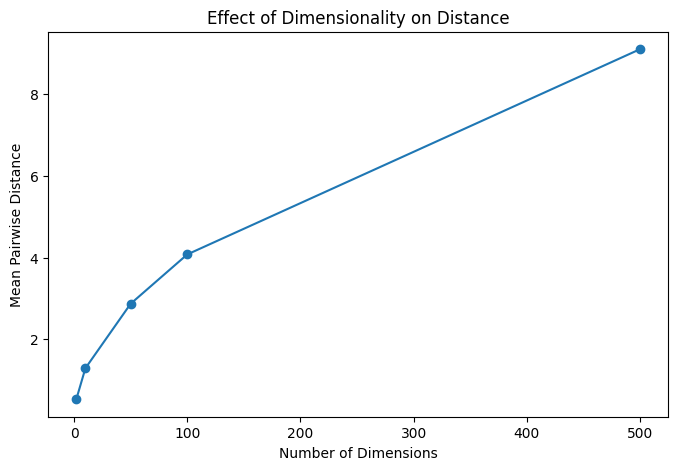

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    distance_df["Dimensions"],
    distance_df["Mean Distance"],
    marker="o"
)

plt.xlabel("Number of Dimensions")
plt.ylabel("Mean Pairwise Distance")

plt.title("Effect of Dimensionality on Distance")

plt.show()

In [8]:
distance_results = []

for d, X in datasets.items():

    distances = pairwise_distances(X)

    non_zero = distances[distances > 0]

    mean_distance = non_zero.mean()
    min_distance = non_zero.min()
    max_distance = non_zero.max()

    distance_results.append({
        "Dimensions": d,
        "Mean": mean_distance,
        "Min": min_distance,
        "Max": max_distance,
        "Max/Min Ratio": max_distance / min_distance
    })

distance_df = pd.DataFrame(distance_results)

distance_df

,Dimensions,Mean,Min,Max,Max/Min Ratio
0,2,0.530910,0.007924,1.291566,163.000960
1,10,1.289361,0.408039,2.042470,5.005570
2,50,2.870075,1.916082,3.682801,1.922047
3,100,4.077597,3.230250,4.954180,1.533683
4,500,9.104488,8.303741,10.035969,1.208608


In [15]:
df = pd.read_csv("/Users/chit/.cache/kagglehub/datasets/abdallahwagih/mall-customers-segmentation/versions/1/Mall_Customers.csv")

df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
X_2d = df[[
    "Age",
    "Annual Income (k$)"
]]


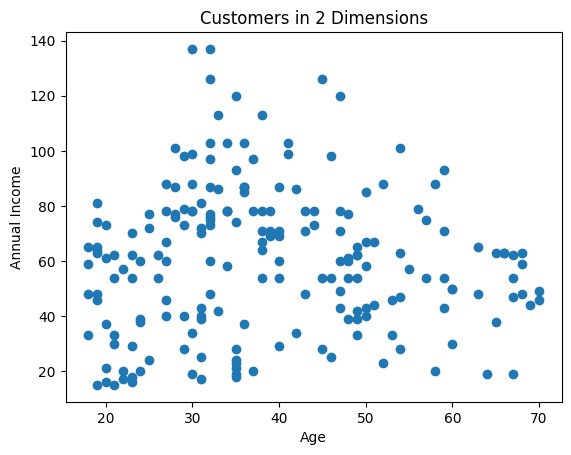

In [17]:
plt.scatter(
    X_2d["Age"],
    X_2d["Annual Income (k$)"]
)

plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title("Customers in 2 Dimensions")
plt.show()


In [18]:
#As dimensions increase, visualization becomes harder.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_2d)

distances = pairwise_distances(X_scaled)

distances

array([[0.        , 0.14353338, 0.08128569, ..., 4.33831279, 4.74921111,
        4.72311171],
       [0.14353338, 0.        , 0.08128569, ..., 4.30972573, 4.72311171,
        4.70125153],
       [0.08128569, 0.08128569, 0.        , ..., 4.2860495 , 4.69810778,
        4.67392732],
       ...,
       [4.33831279, 4.30972573, 4.2860495 , ..., 0.        , 0.41986372,
        0.44371993],
       [4.74921111, 4.72311171, 4.69810778, ..., 0.41986372, 0.        ,
        0.14353338],
       [4.72311171, 4.70125153, 4.67392732, ..., 0.44371993, 0.14353338,
        0.        ]], shape=(200, 200))

In [23]:
X_scaled_2d = scaler.fit_transform(X_2d)

distances_2d = pairwise_distances(X_scaled_2d)

In [26]:
print("2D mean distance:",
      distances[distances > 0].mean())

print("3D mean distance:",
      distances_2d[distances_2d > 0].mean())

2D mean distance: 1.7932847919260007
3D mean distance: 1.7932847919260007


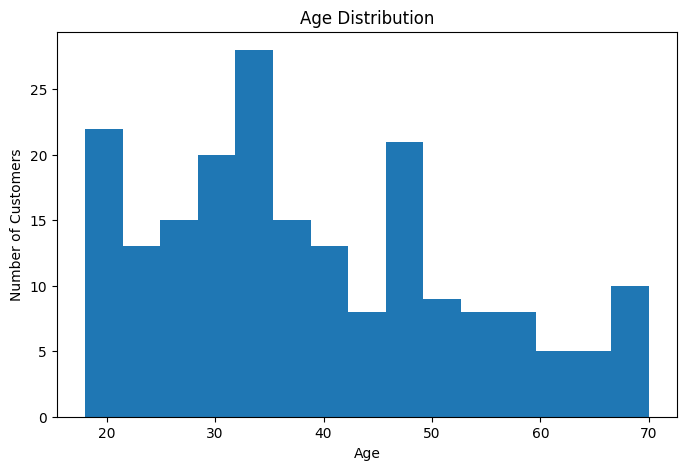

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")

plt.show()

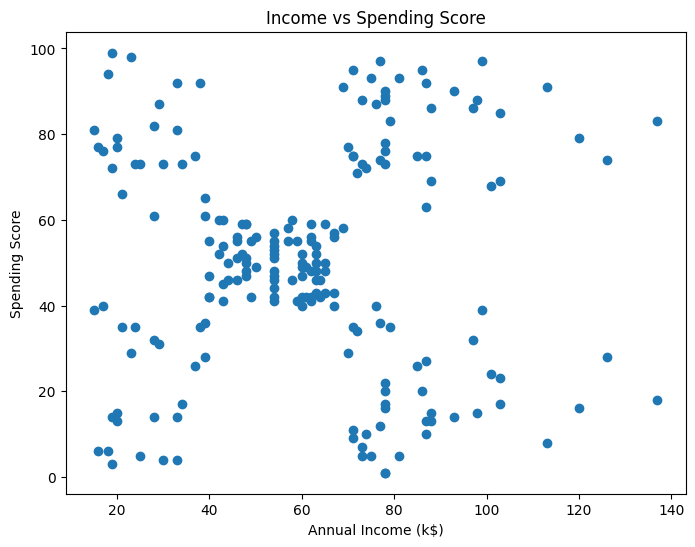

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")

plt.show()

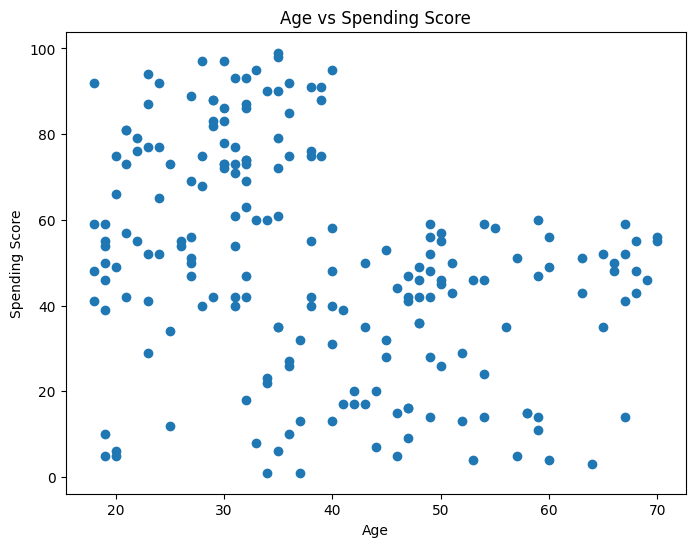

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")

plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [31]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

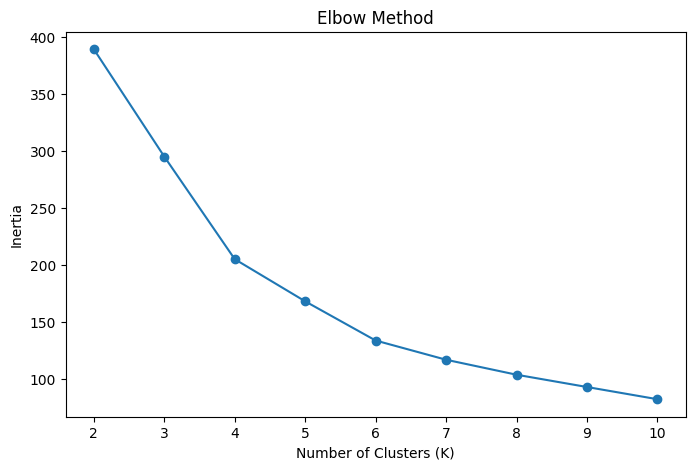

In [32]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [33]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [34]:
df.groupby("Cluster")[features].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [35]:
#Experiment with feature combinations


In [36]:
feature_sets = {

    "2 Features": [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ],

    "3 Features": [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
}

In [37]:
from sklearn.metrics import pairwise_distances

for name, features in feature_sets.items():

    X = df[features]

    X_scaled = StandardScaler().fit_transform(X)

    distances = pairwise_distances(X_scaled)

    non_zero = distances[distances > 0]

    print(name)
    print("Mean distance:", non_zero.mean())
    print("Minimum distance:", non_zero.min())
    print("Maximum distance:", non_zero.max())
    print()

2 Features
Mean distance: 1.7557879749752916
Minimum distance: 0.03816942917176297
Maximum distance: 5.501475005032089

3 Features
Mean distance: 2.2632871248433237
Minimum distance: 0.07176668967516826
Maximum distance: 5.990442868768087



In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(200, 2)

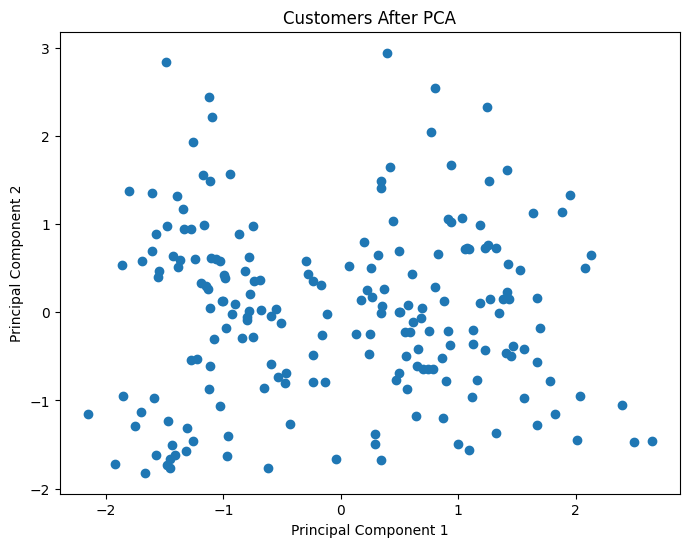

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customers After PCA")

plt.show()